# Epilepsy Machine Learning Analysis

**Course:** COSC2669/COSC2816 – Case Studies in Data Science  
**Case study:** Junior Data Scientist – Australian Epilepsy Project  
**Models:** Gradient Boosting and Multilayer Perceptron (MLP)

## Research question
How effectively can machine learning identify epileptic seizure activity from EEG data across a structured research dataset and a real-world clinical dataset?

This notebook intentionally keeps the two datasets as separate modelling tasks because BEED is a prepared four-class tabular dataset, whereas CHB-MIT contains continuous clinical EEG recordings.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch

import mne

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, LeaveOneGroupOut
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_DIR = Path("data/raw")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print("MNE version:", mne.__version__)

MNE version: 1.12.1


## 1. BEED – Bangalore EEG Epilepsy Dataset

The downloaded CSV contains 8,000 observations with 16 EEG feature columns (`X1`–`X16`) and the target `y`. The four classes are retained:

- 0 = healthy
- 1 = generalised seizure
- 2 = focal seizure
- 3 = seizure event

A stratified five-fold cross-validation design is used so each fold preserves the class proportions.

In [2]:
beed_path = DATA_DIR / "BEED_Data.csv"

if not beed_path.exists():
    raise FileNotFoundError(
        "BEED_Data.csv was not found. Put it in data/raw/ before running the notebook."
    )

beed = pd.read_csv(beed_path)

print("Shape:", beed.shape)
print("\nMissing values:", int(beed.isna().sum().sum()))
print("\nClass counts:")
print(beed["y"].value_counts().sort_index())

X_beed = beed.drop(columns=["y"])
y_beed = beed["y"].astype(int)

Shape: (8000, 17)

Missing values: 0

Class counts:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [3]:
beed_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

gb_beed = GradientBoostingClassifier(random_state=RANDOM_STATE)

mlp_beed = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

def evaluate_beed(model, X, y):
    pred = cross_val_predict(
        model, X, y, cv=beed_cv, method="predict", n_jobs=-1
    )
    prob = cross_val_predict(
        model, X, y, cv=beed_cv, method="predict_proba", n_jobs=-1
    )

    metrics = {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, average="macro"),
        "Recall": recall_score(y, pred, average="macro"),
        "F1": f1_score(y, pred, average="macro"),
        "ROC_AUC": roc_auc_score(
            y, prob, multi_class="ovr", average="macro"
        )
    }
    return metrics, pred, prob

beed_gb_metrics, beed_gb_pred, beed_gb_prob = evaluate_beed(
    gb_beed, X_beed, y_beed
)
beed_mlp_metrics, beed_mlp_pred, beed_mlp_prob = evaluate_beed(
    mlp_beed, X_beed, y_beed
)

beed_results = pd.DataFrame([
    {"Dataset": "BEED", "Model": "Gradient Boosting", **beed_gb_metrics},
    {"Dataset": "BEED", "Model": "MLP", **beed_mlp_metrics},
])

beed_results

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,BEED,Gradient Boosting,0.886375,0.88829,0.886375,0.886412,0.980875
1,BEED,MLP,0.933500,0.93398,0.933500,0.933627,0.992049


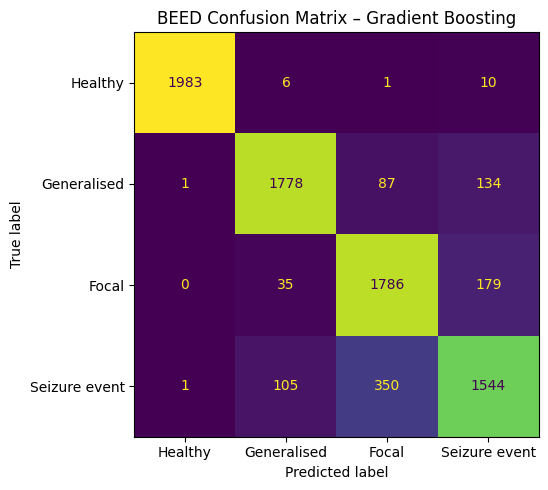

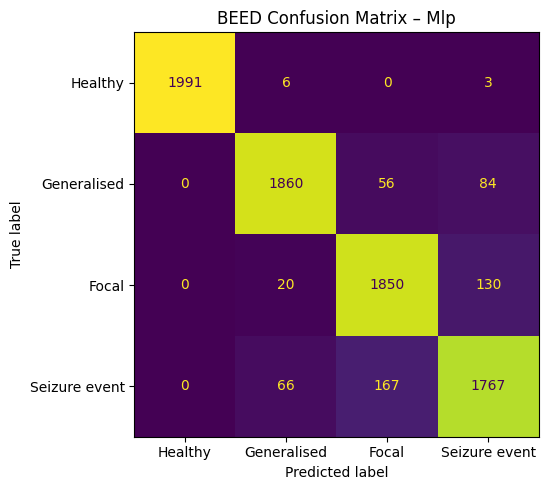

In [4]:
class_names = ["Healthy", "Generalised", "Focal", "Seizure event"]

for name, pred in [
    ("gradient_boosting", beed_gb_pred),
    ("mlp", beed_mlp_pred)
]:
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_beed,
        pred,
        display_labels=class_names,
        cmap=None,
        colorbar=False,
        ax=ax
    )
    ax.set_title(f"BEED Confusion Matrix – {name.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"beed_confusion_matrix_{name}.png", dpi=200)
    plt.show()

## 2. CHB-MIT clinical EEG subset

Seven seizure-containing recordings from `chb01` are used. The seizure intervals below come from the official PhysioNet `chb01-summary.txt` annotation file.

The EEG is divided into 5-second windows. A seizure window must fit fully inside the annotated seizure interval. For every seizure window, one non-seizure window is selected from the same recording at least 60 seconds away from the seizure.

The feature extraction produces 26 aggregate time- and frequency-domain features per window.

In [5]:
SEIZURE_INTERVALS = {
    "chb01_03.edf": (2996, 3036),
    "chb01_04.edf": (1467, 1494),
    "chb01_15.edf": (1732, 1772),
    "chb01_16.edf": (1015, 1066),
    "chb01_18.edf": (1720, 1810),
    "chb01_21.edf": (327, 420),
    "chb01_26.edf": (1862, 1963),
}

WINDOW_SECONDS = 5
SAFETY_MARGIN_SECONDS = 60

for filename in ["chb01_01.edf", *SEIZURE_INTERVALS.keys()]:
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"{filename} was not found. Put all required EDF files in data/raw/."
        )

In [6]:
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_NAMES = []
for name in ["mean", "std", "rms", "ptp", "line_length", "zero_cross_rate"]:
    FEATURE_NAMES.extend([f"{name}_mean_ch", f"{name}_std_ch"])

for name in list(BANDS) + ["total_power", "spectral_entropy"]:
    FEATURE_NAMES.extend([f"{name}_mean_ch", f"{name}_std_ch"])

print("Number of engineered features:", len(FEATURE_NAMES))


def aggregate_window_features(data, sfreq):
    """Convert one channels x samples EEG window into 26 aggregate features."""
    eps = 1e-12

    ch_mean = np.mean(data, axis=1)
    ch_std = np.std(data, axis=1)
    ch_rms = np.sqrt(np.mean(data ** 2, axis=1))
    ch_ptp = np.ptp(data, axis=1)
    ch_line_length = np.mean(np.abs(np.diff(data, axis=1)), axis=1)

    centered = data - ch_mean[:, None]
    ch_zero_cross = np.mean(
        (centered[:, :-1] * centered[:, 1:]) < 0,
        axis=1
    )

    freqs, psd = welch(
        data,
        fs=sfreq,
        nperseg=min(512, data.shape[1]),
        axis=1
    )

    total_mask = (freqs >= 0.5) & (freqs <= 45)
    total_power = np.trapezoid(
        psd[:, total_mask],
        freqs[total_mask],
        axis=1
    ) + eps

    relative_band_power = {}
    for band, (low, high) in BANDS.items():
        band_mask = (freqs >= low) & (freqs < high)
        band_power = np.trapezoid(
            psd[:, band_mask],
            freqs[band_mask],
            axis=1
        )
        relative_band_power[band] = band_power / total_power

    p = psd[:, total_mask]
    p_norm = p / (p.sum(axis=1, keepdims=True) + eps)
    spectral_entropy = -np.sum(
        p_norm * np.log(p_norm + eps),
        axis=1
    ) / np.log(p_norm.shape[1])

    channel_features = [
        ch_mean,
        ch_std,
        ch_rms,
        ch_ptp,
        ch_line_length,
        ch_zero_cross,
        *[relative_band_power[b] for b in BANDS],
        total_power,
        spectral_entropy,
    ]

    output = []
    for values in channel_features:
        output.extend([float(np.mean(values)), float(np.std(values))])

    return output

Number of engineered features: 26


In [7]:
def extract_windows_from_recording(
    filepath,
    seizure_start,
    seizure_end,
    window_seconds=WINDOW_SECONDS,
    safety_margin=SAFETY_MARGIN_SECONDS
):
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    sfreq = float(raw.info["sfreq"])
    duration = raw.n_times / sfreq

    # Full 5-second windows entirely inside the annotated seizure.
    n_seizure = int((seizure_end - seizure_start) // window_seconds)

    seizure_starts = [
        seizure_start + i * window_seconds
        for i in range(n_seizure)
    ]

    # Candidate non-seizure windows at least 60 seconds from seizure.
    candidate_nonseizure = []
    for start in np.arange(
        0,
        duration - window_seconds + 1e-9,
        window_seconds
    ):
        end = start + window_seconds

        safely_before = end <= seizure_start - safety_margin
        safely_after = start >= seizure_end + safety_margin

        if safely_before or safely_after:
            candidate_nonseizure.append(float(start))

    # Select the same number of non-seizure windows, spread across
    # the available safe recording period.
    selected_indices = np.linspace(
        0,
        len(candidate_nonseizure) - 1,
        n_seizure,
        dtype=int
    )

    nonseizure_starts = [
        candidate_nonseizure[i] for i in selected_indices
    ]

    rows = []

    for label, starts in [(1, seizure_starts), (0, nonseizure_starts)]:
        for start in starts:
            start_sample = int(round(start * sfreq))
            stop_sample = int(round((start + window_seconds) * sfreq))

            data = raw.get_data(
                start=start_sample,
                stop=stop_sample
            )

            features = aggregate_window_features(data, sfreq)

            rows.append(
                features + [
                    label,
                    Path(filepath).name,
                    start
                ]
            )

    return rows

In [8]:
chb_rows = []

for filename, (start, end) in SEIZURE_INTERVALS.items():
    rows = extract_windows_from_recording(
        DATA_DIR / filename,
        start,
        end
    )
    chb_rows.extend(rows)

chb = pd.DataFrame(
    chb_rows,
    columns=FEATURE_NAMES + ["label", "recording", "start_sec"]
)

print("CHB-MIT modelling table shape:", chb.shape)
print("\nClass counts:")
print(chb["label"].value_counts())
print("\nWindows per recording:")
print(chb.groupby(["recording", "label"]).size())

chb.head()

CHB-MIT modelling table shape: (174, 29)

Class counts:
label
1    87
0    87
Name: count, dtype: int64

Windows per recording:
recording     label
chb01_03.edf  0         8
              1         8
chb01_04.edf  0         5
              1         5
chb01_15.edf  0         8
              1         8
chb01_16.edf  0        10
              1        10
chb01_18.edf  0        18
              1        18
chb01_21.edf  0        18
              1        18
chb01_26.edf  0        20
              1        20
dtype: int64


,mean_mean_ch,mean_std_ch,std_mean_ch,std_std_ch,rms_mean_ch,rms_std_ch,ptp_mean_ch,ptp_std_ch,line_length_mean_ch,line_length_std_ch,...,beta_std_ch,gamma_mean_ch,gamma_std_ch,total_power_mean_ch,total_power_std_ch,spectral_entropy_mean_ch,spectral_entropy_std_ch,label,recording,start_sec
0,-4.887986e-08,0.000004,0.000049,0.000019,0.000049,0.000019,0.000337,0.000150,0.000006,0.000002,...,0.018876,0.009481,0.012564,1.890021e-09,1.209581e-09,0.682912,0.026284,1,chb01_03.edf,2996.0
1,-1.612876e-06,0.000003,0.000104,0.000040,0.000104,0.000040,0.000558,0.000200,0.000016,0.000011,...,0.015776,0.019484,0.021708,1.039769e-08,8.004973e-09,0.560624,0.053576,1,chb01_03.edf,3001.0
2,2.521368e-06,0.000002,0.000088,0.000027,0.000088,0.000027,0.000532,0.000165,0.000021,0.000016,...,0.029857,0.037908,0.044949,7.312951e-09,4.226440e-09,0.619660,0.066253,1,chb01_03.edf,3006.0
3,-2.149307e-06,0.000005,0.000084,0.000024,0.000084,0.000024,0.000495,0.000155,0.000024,0.000021,...,0.042043,0.069550,0.100508,6.773167e-09,4.034831e-09,0.645032,0.098846,1,chb01_03.edf,3011.0
4,1.727929e-06,0.000009,0.000096,0.000029,0.000097,0.000029,0.000580,0.000198,0.000023,0.000016,...,0.027777,0.050118,0.059026,8.323700e-09,4.737436e-09,0.612703,0.073614,1,chb01_03.edf,3016.0


### Recording-level validation

Randomly splitting EEG windows could place highly similar windows from the same seizure episode in both training and test data. To reduce this leakage risk, leave-one-recording-out validation is used. Every fold therefore tests on a complete held-out recording.

In [9]:
X_chb = chb[FEATURE_NAMES].to_numpy()
y_chb = chb["label"].to_numpy()
groups = chb["recording"].to_numpy()

logo = LeaveOneGroupOut()

gb_chb = GradientBoostingClassifier(random_state=RANDOM_STATE)

mlp_chb = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        early_stopping=False,
        random_state=RANDOM_STATE
    ))
])


def grouped_out_of_fold_predictions(model, X, y, groups):
    predictions = np.zeros_like(y)
    probabilities = np.zeros(len(y), dtype=float)

    for train_index, test_index in logo.split(X, y, groups):
        fitted = clone(model)
        fitted.fit(X[train_index], y[train_index])

        predictions[test_index] = fitted.predict(X[test_index])
        probabilities[test_index] = fitted.predict_proba(
            X[test_index]
        )[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions),
        "Recall": recall_score(y, predictions),
        "F1": f1_score(y, predictions),
        "ROC_AUC": roc_auc_score(y, probabilities)
    }

    return metrics, predictions, probabilities


chb_gb_metrics, chb_gb_pred, chb_gb_prob = grouped_out_of_fold_predictions(
    gb_chb, X_chb, y_chb, groups
)

chb_mlp_metrics, chb_mlp_pred, chb_mlp_prob = grouped_out_of_fold_predictions(
    mlp_chb, X_chb, y_chb, groups
)

chb_results = pd.DataFrame([
    {"Dataset": "CHB-MIT", "Model": "Gradient Boosting", **chb_gb_metrics},
    {"Dataset": "CHB-MIT", "Model": "MLP", **chb_mlp_metrics},
])

chb_results

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CHB-MIT,Gradient Boosting,0.959770,0.934783,0.988506,0.960894,0.962611
1,CHB-MIT,MLP,0.977011,0.956044,1.000000,0.977528,0.998282


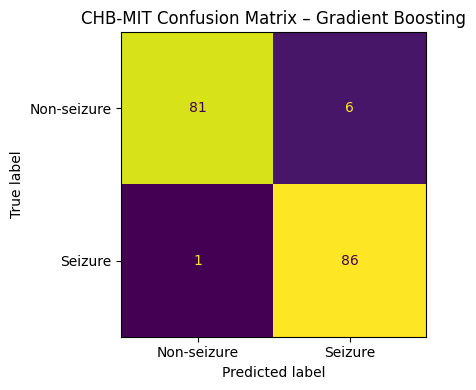

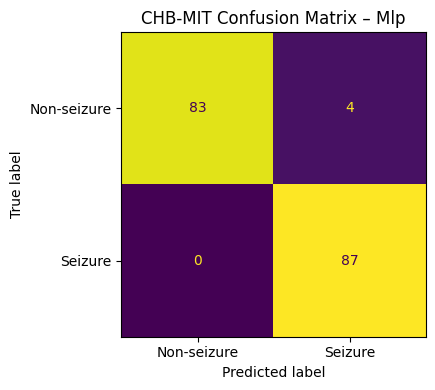

In [10]:
for name, pred in [
    ("gradient_boosting", chb_gb_pred),
    ("mlp", chb_mlp_pred)
]:
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_chb,
        pred,
        display_labels=["Non-seizure", "Seizure"],
        cmap=None,
        colorbar=False,
        ax=ax
    )
    ax.set_title(f"CHB-MIT Confusion Matrix – {name.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"chbmit_confusion_matrix_{name}.png",
        dpi=200
    )
    plt.show()

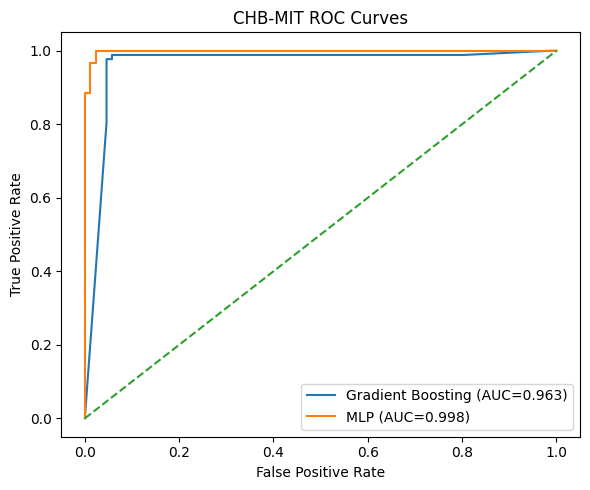

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

for model_name, probabilities in [
    ("Gradient Boosting", chb_gb_prob),
    ("MLP", chb_mlp_prob)
]:
    fpr, tpr, _ = roc_curve(y_chb, probabilities)
    roc_value = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={roc_value:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CHB-MIT ROC Curves")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chbmit_roc_curve.png", dpi=200)
plt.show()

## 3. Combined results

The numbers below are produced directly by the notebook. Use these outputs, not manually typed values, when updating the report.

In [12]:
all_results = pd.concat(
    [beed_results, chb_results],
    ignore_index=True
)

display(all_results)

all_results.to_csv(
    RESULTS_DIR / "model_metrics.csv",
    index=False
)

print("\nSaved results/model_metrics.csv")

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,BEED,Gradient Boosting,0.886375,0.888290,0.886375,0.886412,0.980875
1,BEED,MLP,0.933500,0.933980,0.933500,0.933627,0.992049
2,CHB-MIT,Gradient Boosting,0.959770,0.934783,0.988506,0.960894,0.962611
3,CHB-MIT,MLP,0.977011,0.956044,1.000000,0.977528,0.998282



Saved results/model_metrics.csv


## 4. Interpretation and limitations

Key points to discuss in the assignment:

- BEED and CHB-MIT provide complementary rather than directly comparable evidence.
- BEED tests four-class EEG pattern classification using a prepared tabular dataset.
- CHB-MIT tests binary seizure detection after feature extraction from raw clinical EEG.
- Recall/sensitivity is particularly important in seizure detection because false negatives represent missed seizure activity.
- A higher score on one dataset should not be interpreted as evidence that the dataset or task is easier without considering its structure and validation design.
- BEED lacks participant identifiers in the downloaded table, so patient-level cross-validation cannot be performed.
- CHB-MIT uses only patient `chb01`, so the experiment does not establish cross-patient clinical generalisation.
- The balanced CHB-MIT sample is useful for model comparison but does not reflect the rarity of seizures in continuous clinical monitoring.